In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import sklearn

print("ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY")

ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import sklearn

print("ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY")

ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import sklearn

print("ALL REQUIRED LIBRARIES IMPORTED SUCCESSFULLY")

In [ ]:
data = {
    "review": [
        "This product is excellent and works perfectly",
        "I am very happy with the quality",
        "Amazing product, totally worth the money",
        "The product is good and I would recommend it",
        "Excellent quality and fast delivery",
        "Very useful product and easy to use",
        "I love this product, it is fantastic",
        "Good value for money",
        "The quality is poor and disappointing",
        "I hate this product, completely useless",
        "Very bad quality and stopped working",
        "Waste of money, do not buy this",
        "Terrible product and poor performance",
        "I am disappointed with this purchase",
        "The product broke after two days",
        "Worst product I have ever purchased"
    ],
    "sentiment": [
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative"
    ]
}

df = pd.DataFrame(data)

df.to_csv("product_reviews.csv", index=False)

print("Dataset created successfully!")
print("Number of reviews:", len(df))

Dataset created successfully!
Number of reviews: 16


In [ ]:
df.head()

,review,sentiment
0,This product is excellent and works perfectly,Positive
1,I am very happy with the quality,Positive
2,"Amazing product, totally worth the money",Positive
3,The product is good and I would recommend it,Positive
4,Excellent quality and fast delivery,Positive


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     16 non-null     str  
 1   sentiment  16 non-null     str  
dtypes: str(2)
memory usage: 388.0 bytes


In [ ]:
df.shape

(16, 2)

In [ ]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["cleaned_review"] = df["review"].str.lower()

df[["review", "cleaned_review"]].head()

,review,cleaned_review
0,This product is excellent and works perfectly,this product is excellent and works perfectly
1,I am very happy with the quality,i am very happy with the quality
2,"Amazing product, totally worth the money","amazing product, totally worth the money"
3,The product is good and I would recommend it,the product is good and i would recommend it
4,Excellent quality and fast delivery,excellent quality and fast delivery


In [ ]:
import re

df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)

df[["review", "cleaned_review"]].head()

,review,cleaned_review
0,This product is excellent and works perfectly,this product is excellent and works perfectly
1,I am very happy with the quality,i am very happy with the quality
2,"Amazing product, totally worth the money",amazing product totally worth the money
3,The product is good and I would recommend it,the product is good and i would recommend it
4,Excellent quality and fast delivery,excellent quality and fast delivery


In [ ]:
df["cleaned_review"] = df["cleaned_review"].str.replace(r"\s+", " ", regex=True).str.strip()

df[["review", "cleaned_review"]].head()

,review,cleaned_review
0,This product is excellent and works perfectly,this product is excellent and works perfectly
1,I am very happy with the quality,i am very happy with the quality
2,"Amazing product, totally worth the money",amazing product totally worth the money
3,The product is good and I would recommend it,the product is good and i would recommend it
4,Excellent quality and fast delivery,excellent quality and fast delivery


In [ ]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

df[["review", "cleaned_review"]].head()

,review,cleaned_review
0,This product is excellent and works perfectly,product excellent works perfectly
1,I am very happy with the quality,happy quality
2,"Amazing product, totally worth the money",amazing product totally worth money
3,The product is good and I would recommend it,product good would recommend
4,Excellent quality and fast delivery,excellent quality fast delivery


In [ ]:
df["tokens"] = df["cleaned_review"].apply(lambda x: x.split())

df[["cleaned_review", "tokens"]].head()

,cleaned_review,tokens
0,product excellent works perfectly,"[product, excellent, works, perfectly]"
1,happy quality,"[happy, quality]"
2,amazing product totally worth money,"[amazing, product, totally, worth, money]"
3,product good would recommend,"[product, good, would, recommend]"
4,excellent quality fast delivery,"[excellent, quality, fast, delivery]"


In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["stemmed_review"] = df["tokens"].apply(
    lambda words: " ".join(stemmer.stem(word) for word in words)
)

df[["cleaned_review", "stemmed_review"]].head()

,cleaned_review,stemmed_review
0,product excellent works perfectly,product excel work perfectli
1,happy quality,happi qualiti
2,amazing product totally worth money,amaz product total worth money
3,product good would recommend,product good would recommend
4,excellent quality fast delivery,excel qualiti fast deliveri


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   review          16 non-null     str   
 1   sentiment       16 non-null     str   
 2   cleaned_review  16 non-null     str   
 3   tokens          16 non-null     object
 4   stemmed_review  16 non-null     str   
dtypes: object(1), str(4)
memory usage: 772.0+ bytes


In [ ]:
df.isnull().sum()

review            0
sentiment         0
cleaned_review    0
tokens            0
stemmed_review    0
dtype: int64

In [ ]:
df.duplicated().sum()

TypeError: unhashable type: 'list'

In [ ]:
df.duplicated(subset=["review", "sentiment"]).sum()

np.int64(0)

In [ ]:
df.nunique()

TypeError: unhashable type: 'list'

In [ ]:
print("Unique reviews:", df["review"].nunique())
print("Unique sentiments:", df["sentiment"].nunique())

Unique reviews: 16
Unique sentiments: 2


In [ ]:
print("Sentiment values:")
print(df["sentiment"].unique())

Sentiment values:
<StringArray>
['Positive', 'Negative']
Length: 2, dtype: str


In [ ]:
df["sentiment"].unique()

<StringArray>
['Positive', 'Negative']
Length: 2, dtype: str

In [ ]:
df["sentiment"].value_counts()

sentiment
Positive    8
Negative    8
Name: count, dtype: int64

In [ ]:
df["sentiment"].value_counts(normalize=True) * 100

sentiment
Positive    50.0
Negative    50.0
Name: proportion, dtype: float64

In [ ]:
df.isnull().sum()

review            0
sentiment         0
cleaned_review    0
tokens            0
stemmed_review    0
dtype: int64

In [ ]:
df["sentiment"].value_counts()

sentiment
Positive    8
Negative    8
Name: count, dtype: int64

In [ ]:
df[~df["sentiment"].isin(["Positive", "Negative"])]

,review,sentiment,cleaned_review,tokens,stemmed_review


In [ ]:
valid_sentiments = ["Positive", "Negative"]

incorrect_values = df.loc[
    ~df["sentiment"].isin(valid_sentiments),
    ["review", "sentiment"]
]

print("Number of incorrect sentiment values:", len(incorrect_values))
print(incorrect_values)

Number of incorrect sentiment values: 0
Empty DataFrame
Columns: [review, sentiment]
Index: []


In [ ]:
# Step 4.3: Outlier Detection

review_lengths = df["review"].str.len()

Q1 = review_lengths.quantile(0.25)
Q3 = review_lengths.quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (review_lengths < lower_limit) |
    (review_lengths > upper_limit)
][["review", "sentiment"]]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

print("\nNumber of outliers:", len(outliers))
print("\nOutlier Reviews:")
print(outliers)

Q1: 34.25
Q3: 37.5
IQR: 3.25
Lower Limit: 29.375
Upper Limit: 42.375

Number of outliers: 3

Outlier Reviews:
                                          review sentiment
0  This product is excellent and works perfectly  Positive
3   The product is good and I would recommend it  Positive
7                           Good value for money  Positive


In [ ]:
# Step 4.4: Check for Inconsistent Data

print("Sentiment values:")
print(df["sentiment"].unique())

print("\nSentiment value counts:")
print(df["sentiment"].value_counts())

print("\nEmpty reviews:")
print((df["review"].str.strip() == "").sum())

print("\nReviews with leading/trailing spaces:")
print((df["review"] != df["review"].str.strip()).sum())

Sentiment values:
<StringArray>
['Positive', 'Negative']
Length: 2, dtype: str

Sentiment value counts:
sentiment
Positive    8
Negative    8
Name: count, dtype: int64

Empty reviews:
0

Reviews with leading/trailing spaces:
0


In [ ]:
# Step 4.5: Data Type Conversion

df["review"] = df["review"].astype("string")
df["sentiment"] = df["sentiment"].astype("string")

print("Data types after conversion:")
print(df[["review", "sentiment"]].dtypes)

Data types after conversion:
review       string
sentiment    string
dtype: object


In [ ]:
# Verify Dataset

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape:
(16, 5)

Column Names:
['review', 'sentiment', 'cleaned_review', 'tokens', 'stemmed_review']

Data Types:
review            string
sentiment         string
cleaned_review       str
tokens            object
stemmed_review       str
dtype: object

Missing Values:
review            0
sentiment         0
cleaned_review    0
tokens            0
stemmed_review    0
dtype: int64

First 5 Records:


,review,sentiment,cleaned_review,tokens,stemmed_review
0,This product is excellent and works perfectly,Positive,product excellent works perfectly,"[product, excellent, works, perfectly]",product excel work perfectli
1,I am very happy with the quality,Positive,happy quality,"[happy, quality]",happi qualiti
2,"Amazing product, totally worth the money",Positive,amazing product totally worth money,"[amazing, product, totally, worth, money]",amaz product total worth money
3,The product is good and I would recommend it,Positive,product good would recommend,"[product, good, would, recommend]",product good would recommend
4,Excellent quality and fast delivery,Positive,excellent quality fast delivery,"[excellent, quality, fast, delivery]",excel qualiti fast deliveri


In [ ]:
print("Total Records:", len(df))
print("Positive Reviews:", (df["sentiment"] == "Positive").sum())
print("Negative Reviews:", (df["sentiment"] == "Negative").sum())

Total Records: 16
Positive Reviews: 8
Negative Reviews: 8


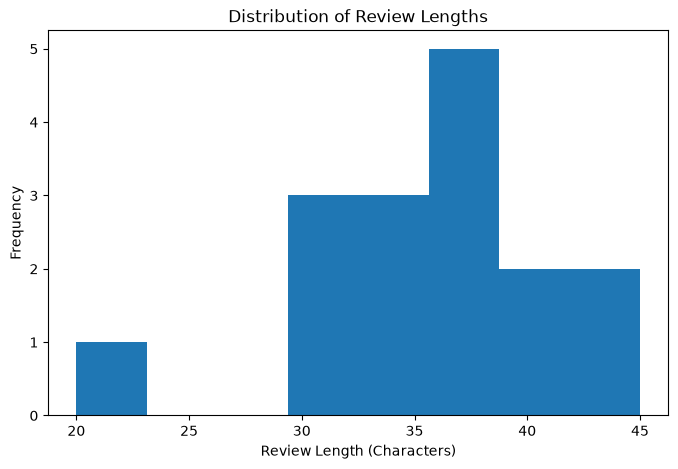

In [ ]:
# Step 5.1: Histogram of Review Length

review_lengths = df["review"].str.len()

plt.figure(figsize=(8, 5))
plt.hist(review_lengths, bins=8)
plt.xlabel("Review Length (Characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Review Lengths")
plt.show()

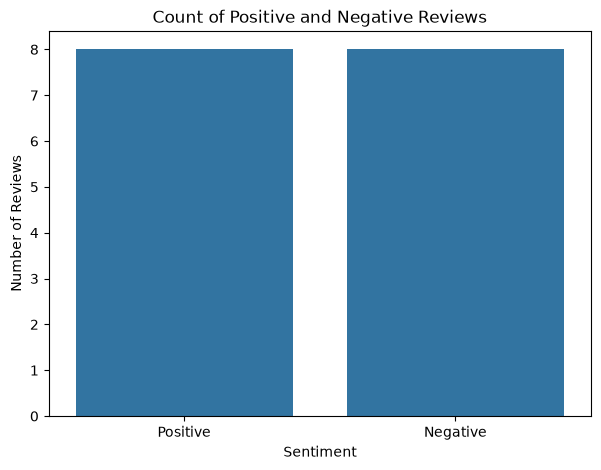

In [ ]:
# Step 5.2: Count Plot of Sentiment

plt.figure(figsize=(7, 5))

sns.countplot(x="sentiment", data=df)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Count of Positive and Negative Reviews")

plt.show()

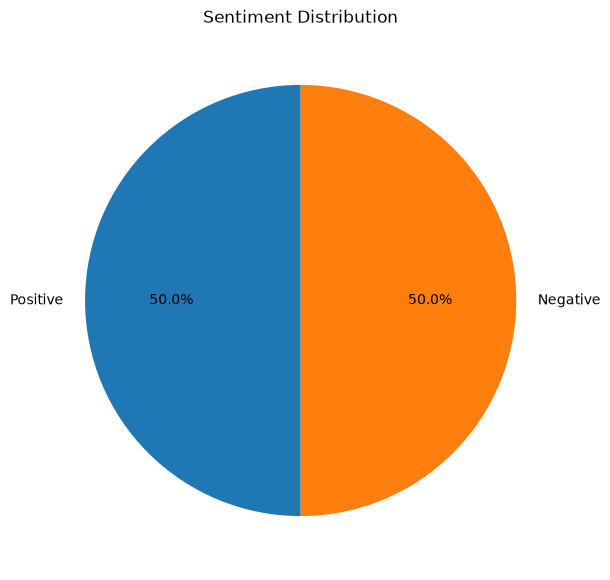

In [ ]:
# Step 5.3: Pie Chart of Sentiment

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sentiment Distribution")
plt.show()

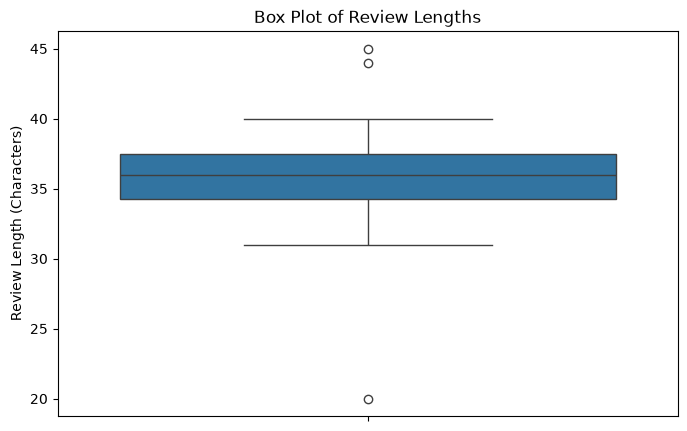

In [ ]:
# Step 5.4: Box Plot of Review Length

review_lengths = df["review"].str.len()

plt.figure(figsize=(8, 5))

sns.boxplot(y=review_lengths)

plt.ylabel("Review Length (Characters)")
plt.title("Box Plot of Review Lengths")

plt.show()

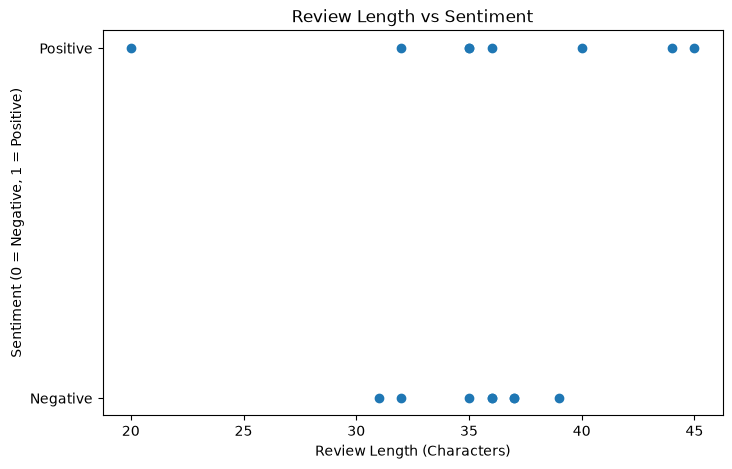

In [ ]:
# Step 5.5: Scatter Plot

review_lengths = df["review"].str.len()

sentiment_numeric = df["sentiment"].map({
    "Negative": 0,
    "Positive": 1
})

plt.figure(figsize=(8, 5))

plt.scatter(review_lengths, sentiment_numeric)

plt.xlabel("Review Length (Characters)")
plt.ylabel("Sentiment (0 = Negative, 1 = Positive)")
plt.title("Review Length vs Sentiment")

plt.yticks([0, 1], ["Negative", "Positive"])

plt.show()

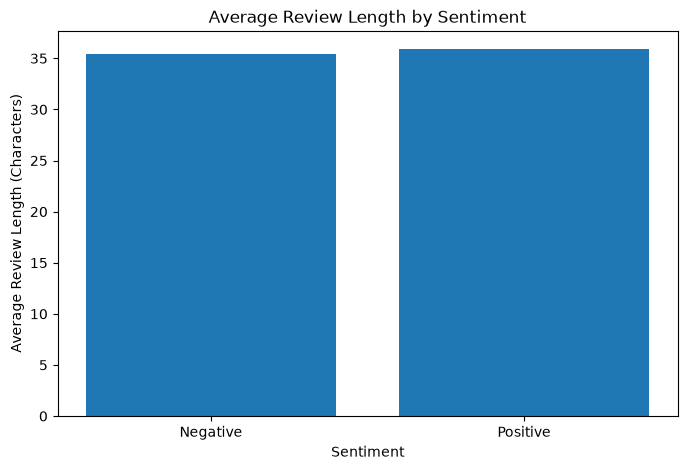

In [ ]:
# Step 5.6: Bar Plot

temp_df = pd.DataFrame({
    "sentiment": df["sentiment"],
    "review_length": df["review"].str.len()
})

avg_review_length = temp_df.groupby("sentiment")["review_length"].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_review_length.index, avg_review_length.values)

plt.xlabel("Sentiment")
plt.ylabel("Average Review Length (Characters)")
plt.title("Average Review Length by Sentiment")

plt.show()

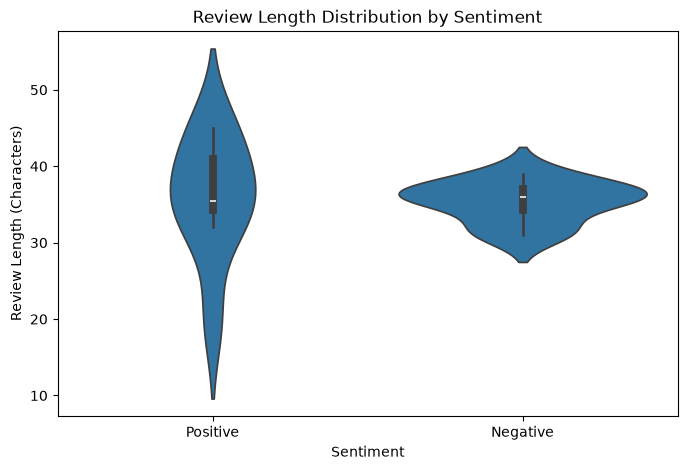

In [ ]:
# Step 5.7: Violin Plot

temp_df = pd.DataFrame({
    "sentiment": df["sentiment"],
    "review_length": df["review"].str.len()
})

plt.figure(figsize=(8, 5))

sns.violinplot(
    x="sentiment",
    y="review_length",
    data=temp_df
)

plt.xlabel("Sentiment")
plt.ylabel("Review Length (Characters)")
plt.title("Review Length Distribution by Sentiment")

plt.show()

In [ ]:
# Step 5.8: Correlation Matrix

correlation_df = pd.DataFrame({
    "review_length": df["review"].str.len(),
    "sentiment_numeric": df["sentiment"].map({
        "Negative": 0,
        "Positive": 1
    })
})

correlation_matrix = correlation_df.corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                   review_length  sentiment_numeric
review_length           1.000000           0.045373
sentiment_numeric       0.045373           1.000000


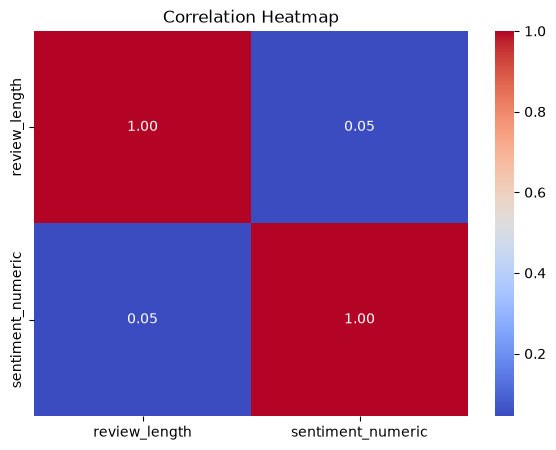

In [ ]:
# Step 5.9: Correlation Heatmap

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

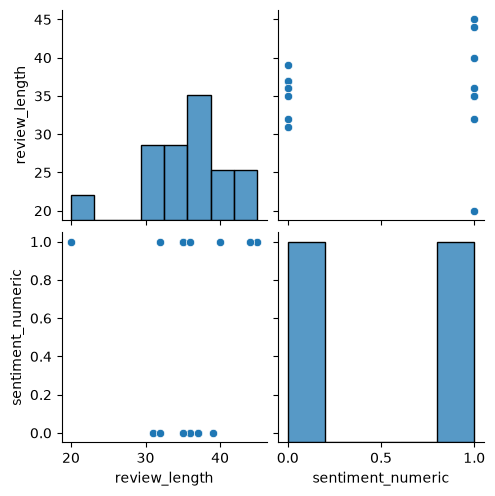

In [ ]:
# Step 5.10: Pairplot

sns.pairplot(correlation_df)

plt.show()

In [ ]:
# Step 6.1: Create New Feature

df["review_length"] = df["review"].str.len()

print("New feature created successfully!")
print(df[["review", "review_length", "sentiment"]].head())

New feature created successfully!
                                          review  review_length sentiment
0  This product is excellent and works perfectly             45  Positive
1               I am very happy with the quality             32  Positive
2       Amazing product, totally worth the money             40  Positive
3   The product is good and I would recommend it             44  Positive
4            Excellent quality and fast delivery             35  Positive


In [ ]:
# Step 6.2: Remove Useless / Intermediate Columns

df = df.drop(columns=["tokens"])

print("Column 'tokens' removed successfully!")
print("\nRemaining columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

Column 'tokens' removed successfully!

Remaining columns:
['review', 'sentiment', 'cleaned_review', 'stemmed_review', 'review_length']

Dataset shape:
(16, 5)


In [ ]:
# Step 6.3: Feature Selection

X = df["cleaned_review"]
y = df["sentiment"]

print("Feature selected: cleaned_review")
print("Target selected: sentiment")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nSample Features:")
print(X.head())

print("\nSample Target:")
print(y.head())

Feature selected: cleaned_review
Target selected: sentiment

Feature shape: (16,)
Target shape: (16,)

Sample Features:
0      product excellent works perfectly
1                          happy quality
2    amazing product totally worth money
3           product good would recommend
4        excellent quality fast delivery
Name: cleaned_review, dtype: str

Sample Target:
0    Positive
1    Positive
2    Positive
3    Positive
4    Positive
Name: sentiment, dtype: string


In [ ]:
# Step 7.1: Encoding Target Variable

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original Target Values:")
print(y.unique())

print("\nEncoded Target Values:")
print(y_encoded)

print("\nClass Mapping:")
for label, encoded in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(label, "=", encoded)

Original Target Values:
<StringArray>
['Positive', 'Negative']
Length: 2, dtype: string

Encoded Target Values:
[1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0]

Class Mapping:
Negative = 0
Positive = 1


In [ ]:
# Step 7.2: TF-IDF Feature Extraction

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X)

print("TF-IDF transformation completed!")
print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF transformation completed!
TF-IDF Matrix Shape: (16, 41)


In [ ]:
# Step 7.3: Standard Scaling

from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler(with_mean=False)

X_standard_scaled = standard_scaler.fit_transform(X_tfidf)

print("StandardScaler applied successfully!")
print("Scaled Matrix Shape:", X_standard_scaled.shape)

StandardScaler applied successfully!
Scaled Matrix Shape: (16, 41)


In [ ]:
# Step 7.4: MinMax Scaling

from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

X_minmax_scaled = minmax_scaler.fit_transform(
    X_tfidf.toarray()
)

print("MinMaxScaler applied successfully!")
print("Scaled Matrix Shape:", X_minmax_scaled.shape)

MinMaxScaler applied successfully!
Scaled Matrix Shape: (16, 41)


In [ ]:
# Step 8: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Train-Test Split Completed!")

print("\nTraining Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Train-Test Split Completed!

Training Features Shape: (12, 41)
Testing Features Shape: (4, 41)

Training Target Shape: (12,)
Testing Target Shape: (4,)


In [ ]:
# Step 9: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

print("\nScaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

Feature Scaling Completed!

Scaled Training Shape: (12, 41)
Scaled Testing Shape: (4, 41)


In [ ]:
# Step 10: Model Selection

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Create models
logistic_model = LogisticRegression(random_state=42)
naive_bayes_model = MultinomialNB()
svm_model = SVC(kernel="linear", probability=True, random_state=42)
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Models selected successfully!")

print("\n1. Logistic Regression")
print("2. Naive Bayes")
print("3. Support Vector Machine")
print("4. Random Forest")

Models selected successfully!

1. Logistic Regression
2. Naive Bayes
3. Support Vector Machine
4. Random Forest


In [ ]:
# Step 11: Model Training

# 1. Logistic Regression
logistic_model.fit(X_train_scaled, y_train)

# 2. Naive Bayes
naive_bayes_model.fit(X_train, y_train)

# 3. Support Vector Machine
svm_model.fit(X_train_scaled, y_train)

# 4. Random Forest
random_forest_model.fit(X_train, y_train)

print("All models trained successfully!")

All models trained successfully!


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [ ]:
# Step 12: Model Prediction

# Logistic Regression Prediction
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Naive Bayes Prediction
y_pred_nb = naive_bayes_model.predict(X_test)

# SVM Prediction
y_pred_svm = svm_model.predict(X_test_scaled)

# Random Forest Prediction
y_pred_rf = random_forest_model.predict(X_test)

print("Predictions completed successfully!")

print("\nActual Values:")
print(y_test)

print("\nLogistic Regression Predictions:")
print(y_pred_logistic)

print("\nNaive Bayes Predictions:")
print(y_pred_nb)

print("\nSVM Predictions:")
print(y_pred_svm)

print("\nRandom Forest Predictions:")
print(y_pred_rf)

Predictions completed successfully!

Actual Values:
[0 1 0 1]

Logistic Regression Predictions:
[1 0 0 0]

Naive Bayes Predictions:
[1 0 1 1]

SVM Predictions:
[1 0 0 0]

Random Forest Predictions:
[1 0 0 0]


In [ ]:
# Step 13: Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Naive Bayes": y_pred_nb,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf
}

for model_name, predictions in models_predictions.items():

    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print("Accuracy :", accuracy_score(y_test, predictions))
    print("Precision:", precision_score(y_test, predictions, zero_division=0))
    print("Recall   :", recall_score(y_test, predictions, zero_division=0))
    print("F1 Score :", f1_score(y_test, predictions, zero_division=0))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print()

Logistic Regression
Accuracy : 0.25
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0

Classification Report:
              precision    recall  f1-score   support

    Negative       0.33      0.50      0.40         2
    Positive       0.00      0.00      0.00         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4

Confusion Matrix:
[[1 1]
 [2 0]]

Naive Bayes
Accuracy : 0.25
Precision: 0.3333333333333333
Recall   : 0.5
F1 Score : 0.4

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         2
    Positive       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4

Confusion Matrix:
[[0 2]
 [1 1]]

SVM
Accuracy : 0.25
Precision: 0.0
Recall   : 0.0
F1 Score : 

In [ ]:
# Step 14: Compare Multiple Models

comparison_results = []

for model_name, predictions in models_predictions.items():
    comparison_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0)
    })

comparison_df = pd.DataFrame(comparison_results)

print("Model Comparison:")
display(comparison_df)

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.25,0.000000,0.0,0.0
1,Naive Bayes,0.25,0.333333,0.5,0.4
2,SVM,0.25,0.000000,0.0,0.0
3,Random Forest,0.25,0.000000,0.0,0.0


In [ ]:
# Sort models by F1 Score

comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

print("Models Ranked by F1 Score:")
display(comparison_df)

Models Ranked by F1 Score:


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.25,0.333333,0.5,0.4
1,Logistic Regression,0.25,0.000000,0.0,0.0
2,SVM,0.25,0.000000,0.0,0.0
3,Random Forest,0.25,0.000000,0.0,0.0


In [ ]:
# Step 15: Cross Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation scores
cv_logistic = cross_val_score(
    logistic_model,
    X_tfidf,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

cv_nb = cross_val_score(
    naive_bayes_model,
    X_tfidf,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

cv_svm = cross_val_score(
    svm_model,
    X_tfidf,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

cv_rf = cross_val_score(
    random_forest_model,
    X_tfidf,
    y_encoded,
    cv=cv,
    scoring="accuracy"
)

print("Cross Validation Results")
print("=" * 40)

print("Logistic Regression:", cv_logistic)
print("Mean Accuracy:", cv_logistic.mean())

print("\nNaive Bayes:", cv_nb)
print("Mean Accuracy:", cv_nb.mean())

print("\nSVM:", cv_svm)
print("Mean Accuracy:", cv_svm.mean())

print("\nRandom Forest:", cv_rf)
print("Mean Accuracy:", cv_rf.mean())

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\

Cross Validation Results
Logistic Regression: [0.5        0.33333333 0.33333333 0.33333333 0.33333333]
Mean Accuracy: 0.3666666666666666

Naive Bayes: [0.5        0.66666667 0.33333333 0.66666667 0.33333333]
Mean Accuracy: 0.5

SVM: [0.75       0.33333333 0.33333333 0.66666667 0.33333333]
Mean Accuracy: 0.4833333333333333

Random Forest: [0.5        0.33333333 0.33333333 0.33333333 0.33333333]
Mean Accuracy: 0.3666666666666666


In [ ]:
# Step 16: Save the Best Model and TF-IDF Vectorizer

import joblib

# Select the best model based on cross-validation accuracy
best_model = naive_bayes_model

# Save the trained model
joblib.dump(best_model, "product_review_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save the label encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model saved successfully!")
print("TF-IDF vectorizer saved successfully!")
print("Label encoder saved successfully!")

Model saved successfully!
TF-IDF vectorizer saved successfully!
Label encoder saved successfully!


In [ ]:
import os

print("Saved Files:")

for file in [
    "product_review_model.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder.pkl"
]:
    print(file, "→", os.path.exists(file))

Saved Files:
product_review_model.pkl → True
tfidf_vectorizer.pkl → True
label_encoder.pkl → True


In [ ]:
# Step 17.1: Load Saved Model and Preprocessing Objects

import joblib

loaded_model = joblib.load("product_review_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")
loaded_encoder = joblib.load("label_encoder.pkl")

print("Saved model loaded successfully!")
print("TF-IDF vectorizer loaded successfully!")
print("Label encoder loaded successfully!")

Saved model loaded successfully!
TF-IDF vectorizer loaded successfully!
Label encoder loaded successfully!


In [ ]:
# Step 17.2: Test Saved Model with New Data

new_reviews = [
    "This product is amazing and I love it",
    "Very poor quality and completely useless",
    "Excellent product, I am very satisfied",
    "Terrible product, waste of money"
]

# Convert new reviews into TF-IDF features
new_reviews_tfidf = loaded_tfidf.transform(new_reviews)

# Make predictions
new_predictions = loaded_model.predict(new_reviews_tfidf)

# Convert numeric predictions back to labels
predicted_sentiments = loaded_encoder.inverse_transform(new_predictions)

print("New Review Predictions:")
print("=" * 50)

for review, sentiment in zip(new_reviews, predicted_sentiments):
    print("Review:", review)
    print("Predicted Sentiment:", sentiment)
    print("-" * 50)

New Review Predictions:
Review: This product is amazing and I love it
Predicted Sentiment: Positive
--------------------------------------------------
Review: Very poor quality and completely useless
Predicted Sentiment: Negative
--------------------------------------------------
Review: Excellent product, I am very satisfied
Predicted Sentiment: Positive
--------------------------------------------------
Review: Terrible product, waste of money
Predicted Sentiment: Positive
--------------------------------------------------


In [ ]:
# Step 18.1: Create Streamlit Application

app_code = '''
import streamlit as st
import joblib

# Load saved model and preprocessing objects
model = joblib.load("product_review_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")
label_encoder = joblib.load("label_encoder.pkl")

# Page configuration
st.set_page_config(
    page_title="Product Review Classification",
    page_icon="🛍️"
)

st.title("🛍️ Product Review Classification")
st.write("Enter a product review to predict its sentiment.")

# User input
review = st.text_area(
    "Enter your product review:",
    placeholder="Example: This product is excellent and I love it!"
)

# Prediction button
if st.button("Predict Sentiment"):

    if review.strip() == "":
        st.warning("Please enter a review.")

    else:
        # Convert review to TF-IDF
        review_tfidf = tfidf.transform([review])

        # Make prediction
        prediction = model.predict(review_tfidf)

        # Convert prediction to label
        sentiment = label_encoder.inverse_transform(prediction)[0]

        # Display result
        if sentiment == "Positive":
            st.success("😊 Positive Review")

        else:
            st.error("😞 Negative Review")
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully!")

app.py created successfully!
